## __HYDROGEN MOLECULE EXCITED__ ##

__Pada simulasi kali ini__ tidak hanya menghitung energi ground state nya, tapi juga energi keadaan terksitasi dari moelkul H2

    Hasil dari simulasi ini memberikan gambaran yang lebih lengkap mengenai struktur energi molekul. Tidak hanya menunjukkan kondisi paling stabil tetapi juga bagaimana sistem berperilaku ketika berada pada tingkat energi yang lebih tinggi.

### __1. IMPORT LIBRARIES__ ###

In [2]:
import numpy as np
from scipy.sparse import linalg

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

### __2. INISIALISASI__ ###

In [4]:
#membuat list 40 panjang ikatan dari hidrogen
bond_lengths = np.linspace(0.2, 3.5, num=40)

#1 adalah energi terendah dan 2 adalah energi tereksitasi
energy_levels = 2

#membuat array untuk menyimpan energi terendah dan keadaan eksitasi
energy = []

### __3. SIMULATE TEH GROUND STATE ENERGY OF THE HYDROGEN MOLECULE AT EACH BOND LENGTH__ ##

In [5]:
for bond_length in bond_lengths:
    #mengatur parameter molekul
    geometry = [('H', (0, 0, 0)), ('H', (0, 0, bond_length))]
    basis = 'sto-3g'
    multiplicity = 1
    charge = 0

    #menampilkan struktur elektronik dan obtain hamiltonian
    hamiltonian = ofpyscf.generate_molecular_hamiltonian(geometry, basis, multiplicity, charge)

    #convert to a fermionic operator
    hamiltonian_ferm_op = of.get_fermion_operator(hamiltonian)

    #map to qubit operator using Bravyi-Kitaev transformation
    hamiltonian_bk = of.bravyi_kitaev(hamiltonian_ferm_op)

    #convert to scipy sparse matrix
    hamiltonian_bk_sparse = of.get_sparse_operator(hamiltonian_bk)

    #menghitung energi terendah dan keadaan eksitasi menggunakan eigsh
    eigs, _ = linalg.eigsh(hamiltonian_bk_sparse, k=energy_levels, which='SA')
    ground_excited_energies = eigs #[1] #[0]

    #menyimpan energi terendah dan keadaan eksitasi di array
    if bond_length == bond_lengths[0]:
        energy = np.array(ground_excited_energies)
    else:
        energy = np.vstack((energy, ground_excited_energies))

### __4. PLOT__ ###

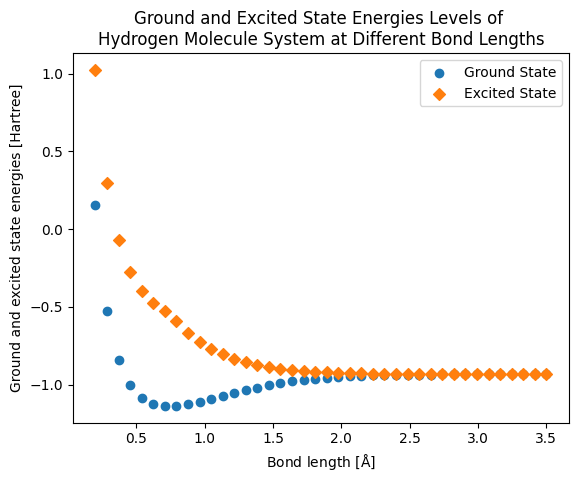

In [6]:
markers = ["o", "D"]
for i in range(energy_levels):
    plt.scatter(bond_lengths, energy[:,i:i+1], marker = markers[i])

# Add labels, title and legend on the plot
plt.xlabel('Bond length [$\mathrm{\AA}$]')
plt.ylabel('Ground and excited state energies [Hartree]')
plt.title('Ground and Excited State Energies Levels of \n'
          'Hydrogen Molecule System at Different Bond Lengths')
plt.legend(["Ground State", "Excited State"])
plt.show()